Mounted at /content/drive
===== PARAMETROS AJUSTADOS =====
tau = 1.8010 s
v0x = 12.0042 m/s
v0y = 10.0021 m/s
v0  = 15.6250 m/s
theta0 = 39.8016 grados


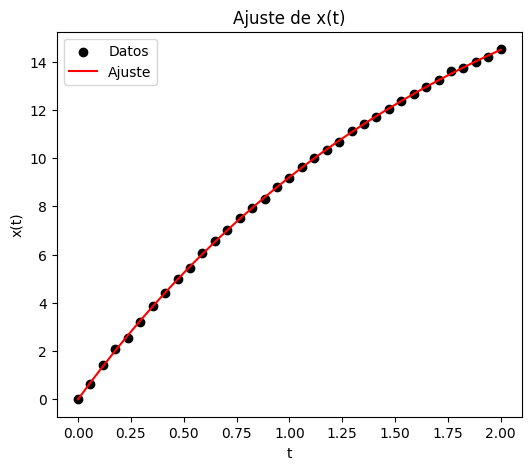

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

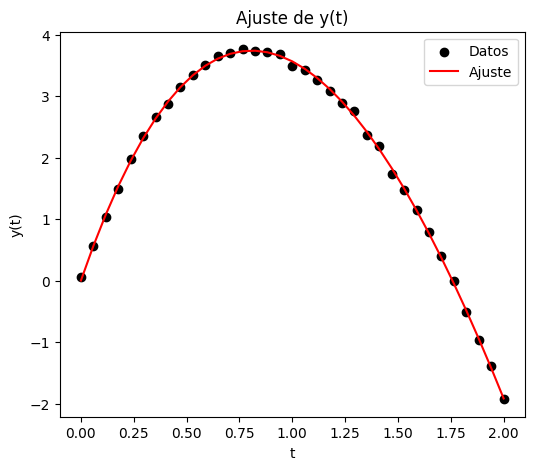

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

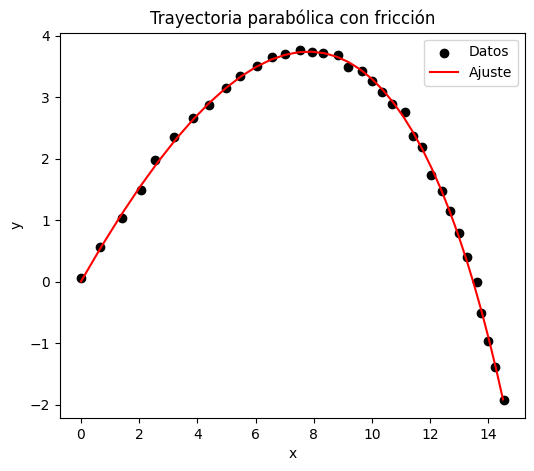

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

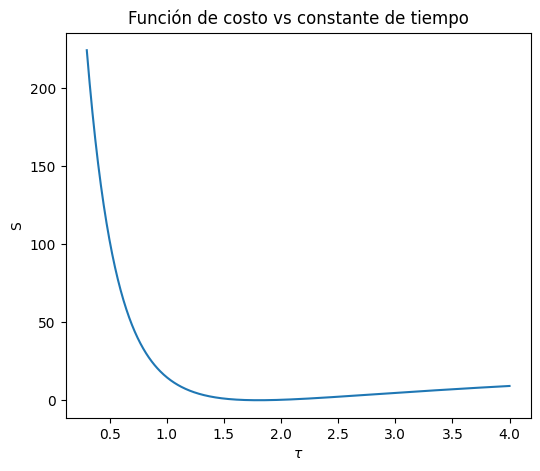

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
from google.colab import drive
drive.mount('/content/drive')
from google.colab import files

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# =====================================================
# LEER DATOS
# =====================================================

carpeta = "/content/drive/MyDrive/Proyecto_FisicaA/FisicaA/Data/"
archivo = "Proyecto1/Trayectoria_parabolica_friccion.csv"
ruta = os.path.join(carpeta, archivo)

df = pd.read_csv(ruta)

t = df["time"].values
x_datos = df["x"].values
y_datos = df["y"].values

g = 9.81

# =====================================================
# AJUSTE POR MINIMOS CUADRADOS
# =====================================================

taus = np.linspace(0.3, 4.0, 600)

S_total = []
v0x_list = []
v0y_list = []

for tau in taus:
    A = tau * (1 - np.exp(-t / tau))

    # Ajuste para v0x
    v0x = np.sum(A * x_datos) / np.sum(A**2)

    # Ajuste para v0y
    Yprima = y_datos - g * tau * A + g * tau * t
    v0y = np.sum(A * Yprima) / np.sum(A**2)

    # Modelo
    x_modelo = v0x * A
    y_modelo = A * v0y + g * tau * A - g * tau * t

    # Funcion de costo
    S = np.sum((x_datos - x_modelo)**2) + np.sum((y_datos - y_modelo)**2)

    S_total.append(S)
    v0x_list.append(v0x)
    v0y_list.append(v0y)

S_total = np.array(S_total)
v0x_list = np.array(v0x_list)
v0y_list = np.array(v0y_list)

# Mejor ajuste
idx = np.argmin(S_total)
tau_best = taus[idx]
v0x_best = v0x_list[idx]
v0y_best = v0y_list[idx]

v0_best = np.sqrt(v0x_best**2 + v0y_best**2)
theta_best = np.degrees(np.arctan2(v0y_best, v0x_best))

print("===== PARAMETROS AJUSTADOS =====")
print(f"tau = {tau_best:.4f} s")
print(f"v0x = {v0x_best:.4f} m/s")
print(f"v0y = {v0y_best:.4f} m/s")
print(f"v0  = {v0_best:.4f} m/s")
print(f"theta0 = {theta_best:.4f} grados")

# =====================================================
# MODELO FINAL
# =====================================================

A_best = tau_best * (1 - np.exp(-t / tau_best))
x_fit = v0x_best * A_best
y_fit = tau_best * (v0y_best + g * tau_best) * (1 - np.exp(-t / tau_best)) - g * tau_best * t

# =====================================================
# GRAFICA 1: x(t)
# =====================================================

plt.figure(figsize=(6,5))
plt.scatter(t, x_datos, color='k', label="Datos")
plt.plot(t, x_fit, color='r', label="Ajuste")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Ajuste de x(t)")
plt.legend()

ruta_fig1 = os.path.join(carpeta, "Proyecto_xt.pdf")
plt.savefig(ruta_fig1, dpi=300, bbox_inches="tight")
plt.show()
files.download(ruta_fig1)

# =====================================================
# GRAFICA 2: y(t)
# =====================================================

plt.figure(figsize=(6,5))
plt.scatter(t, y_datos, color='k', label="Datos")
plt.plot(t, y_fit, color='r', label="Ajuste")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("Ajuste de y(t)")
plt.legend()

ruta_fig2 = os.path.join(carpeta, "Proyecto_yt.pdf")
plt.savefig(ruta_fig2, dpi=300, bbox_inches="tight")
plt.show()
files.download(ruta_fig2)

# =====================================================
# GRAFICA 3: TRAYECTORIA y(x)
# =====================================================

plt.figure(figsize=(6,5))
plt.scatter(x_datos, y_datos, color='k', label="Datos")
plt.plot(x_fit, y_fit, color='r', label="Ajuste")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Trayectoria parabólica con fricción")
plt.legend()

ruta_fig3 = os.path.join(carpeta, "Proyecto_trayectoria.pdf")
plt.savefig(ruta_fig3, dpi=300, bbox_inches="tight")
plt.show()
files.download(ruta_fig3)

# =====================================================
# GRAFICA 4: FUNCION DE COSTO vs tau
# =====================================================

plt.figure(figsize=(6,5))
plt.plot(taus, S_total)
plt.xlabel(r"$\tau$")
plt.ylabel("S")
plt.title("Función de costo vs constante de tiempo")

ruta_fig4 = os.path.join(carpeta, "Proyecto_costo_tau.pdf")
plt.savefig(ruta_fig4, dpi=300, bbox_inches="tight")
plt.show()
files.download(ruta_fig4)